# Домашнее задание 2 по дисциплине "Методы машинного обучения"

**Задача 1.**
1. Сгенерировать датасет при помощи `sklearn.datasets.make_regression`.
2. Обучить линейную модель при помощи градиентного спуска (batch gradient descent) и стохастического градиентного спуска (stochastic gradient descent).
3. Построить на одном графике среднеквадратичную ошибку (MSE) в зависимости от номера эпохи для обоих методов.
4. Сделать выводы о скорости сходимости каждого из методов.

**Задача 2.**
1. Модифицировать решение первой задачи, добавив L2-регуляризацию (в функцию, считающую MSE, нужно добавить норму вектора весов).
2. Сравнить результаты обучения с регуляризацией и без неё.



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [8]:
np.random.seed(42)

# Генерация синтетического датасета для регрессии
X, y = make_regression(
    n_samples=1000,
    n_features=10,
    n_informative=10,
    noise=15.0,
    random_state=42
)

In [9]:
# Стандартизируем признаки для более стабильного обучения
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Добавим столбец единиц для свободного члена (bias)
X_bias = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])

In [10]:
# делим выборку для обучения
X_train, X_test, y_train, y_test = train_test_split(
    X_bias, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((800, 11), (200, 11))

In [11]:
def mse(y_true, y_pred):
    """Среднеквадратичная ошибка (без регуляризации)."""
    return np.mean((y_true - y_pred) ** 2)

In [12]:
def predict(X, w):
    return X @ w

In [13]:
def gradient_descent(X, y, lr=0.01, n_epochs=200):
    """Batch gradient descent для линейной регрессии.

    Возвращает историю весов и ошибок на обучающей выборке.
    """
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    mse_history = []

    for epoch in range(n_epochs):
        y_pred = predict(X, w)
        error = y_pred - y
        grad = (2 / n_samples) * (X.T @ error)  # градиент MSE по w
        w -= lr * grad

        mse_value = mse(y, predict(X, w))
        mse_history.append(mse_value)

    return w, mse_history

In [14]:
def stochastic_gradient_descent(X, y, lr=0.01, n_epochs=50, shuffle=True):
    """Stochastic gradient descent (обновление по одному объекту).

    Возвращает историю среднеквадратичной ошибки по эпохам.
    """
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    mse_history = []

    for epoch in range(n_epochs):
        if shuffle:
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
        else:
            X_shuffled = X
            y_shuffled = y

        for i in range(n_samples):
            x_i = X_shuffled[i]
            y_i = y_shuffled[i]
            y_pred_i = x_i @ w
            error_i = y_pred_i - y_i
            grad_i = 2 * error_i * x_i  # градиент для одного объекта
            w -= lr * grad_i

        mse_value = mse(y, predict(X, w))
        mse_history.append(mse_value)

    return w, mse_history


In [15]:
# Обучение градиентным спуском (batch GD)

lr_gd = 0.05
n_epochs_gd = 200

w_gd, mse_history_gd = gradient_descent(X_train, y_train, lr=lr_gd, n_epochs=n_epochs_gd)


In [16]:
# Обучение стохастическим градиентным спуском (SGD)

lr_sgd = 0.01
n_epochs_sgd = 50

w_sgd, mse_history_sgd = stochastic_gradient_descent(
    X_train, y_train, lr=lr_sgd, n_epochs=n_epochs_sgd, shuffle=True
)

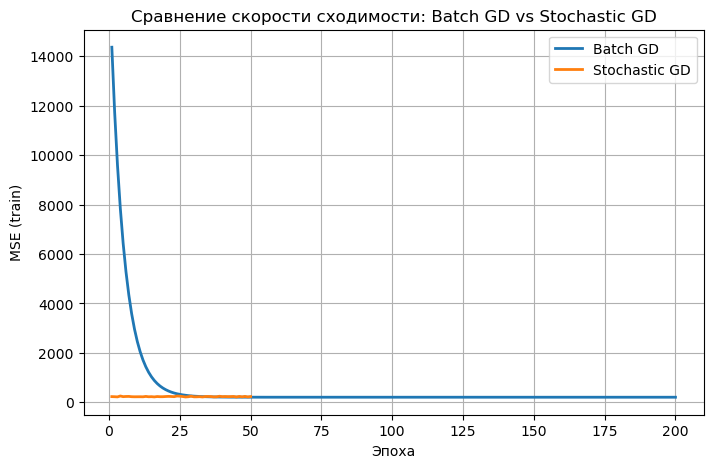

Конечная MSE (GD): 208.53240084115262
Конечная MSE (SGD): 235.42603036027685


In [17]:
# Построим графики MSE по эпохам для обоих методов
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(mse_history_gd) + 1), mse_history_gd, label="Batch GD", linewidth=2)
plt.plot(range(1, len(mse_history_sgd) + 1), mse_history_sgd, label="Stochastic GD", linewidth=2)
plt.xlabel("Эпоха")
plt.ylabel("MSE (train)")
plt.title("Сравнение скорости сходимости: Batch GD vs Stochastic GD")
plt.legend()
plt.grid(True)
plt.show()

print("Конечная MSE (GD):", mse_history_gd[-1])
print("Конечная MSE (SGD):", mse_history_sgd[-1])


In [18]:
def mse_l2(y_true, y_pred, w, alpha=0.1):
    """MSE с L2-регуляризацией (ridge): MSE + alpha * ||w||^2.

    Свободный член (bias) не штрафуем: норму считаем только по остальным весам.
    """
    # w[0] — bias, не включаем его в регуляризацию
    w_no_bias = w[1:]
    return np.mean((y_true - y_pred) ** 2) + alpha * np.sum(w_no_bias ** 2)

In [19]:
def gradient_descent_l2(X, y, lr=0.01, n_epochs=200, alpha=0.1):
    """Batch GD с L2-регуляризацией."""
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    mse_history = []

    for epoch in range(n_epochs):
        y_pred = predict(X, w)
        error = y_pred - y
        grad_mse = (2 / n_samples) * (X.T @ error)

        # Градиент регуляризатора: 2 * alpha * w, но без bias
        grad_reg = 2 * alpha * w
        grad_reg[0] = 0.0

        grad = grad_mse + grad_reg
        w -= lr * grad

        mse_value = mse_l2(y, predict(X, w), w, alpha=alpha)
        mse_history.append(mse_value)

    return w, mse_history

In [20]:
def stochastic_gradient_descent_l2(X, y, lr=0.01, n_epochs=50, alpha=0.1, shuffle=True):
    """SGD с L2-регуляризацией."""
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    mse_history = []

    for epoch in range(n_epochs):
        if shuffle:
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
        else:
            X_shuffled = X
            y_shuffled = y

        for i in range(n_samples):
            x_i = X_shuffled[i]
            y_i = y_shuffled[i]
            y_pred_i = x_i @ w
            error_i = y_pred_i - y_i

            # Градиент по одному объекту + L2 к весам, кроме bias
            grad_i = 2 * error_i * x_i
            grad_reg = 2 * alpha * w
            grad_reg[0] = 0.0

            w -= lr * (grad_i + grad_reg)

        mse_value = mse_l2(y, predict(X, w), w, alpha=alpha)
        mse_history.append(mse_value)

    return w, mse_history


In [21]:
# Сравнение обучения с L2-регуляризацией и без неё

alpha = 0.001

# Batch GD: без регуляризации и с регуляризацией
w_gd_base, mse_gd_base = gradient_descent(X_train, y_train, lr=lr_gd, n_epochs=n_epochs_gd)
w_gd_l2, mse_gd_l2 = gradient_descent_l2(X_train, y_train, lr=lr_gd, n_epochs=n_epochs_gd, alpha=alpha)

# SGD: без регуляризации и с регуляризацией
w_sgd_base, mse_sgd_base = stochastic_gradient_descent(
    X_train, y_train, lr=lr_sgd, n_epochs=n_epochs_sgd, shuffle=True
)
w_sgd_l2, mse_sgd_l2 = stochastic_gradient_descent_l2(
    X_train, y_train, lr=lr_sgd, n_epochs=n_epochs_sgd, alpha=alpha, shuffle=True
)

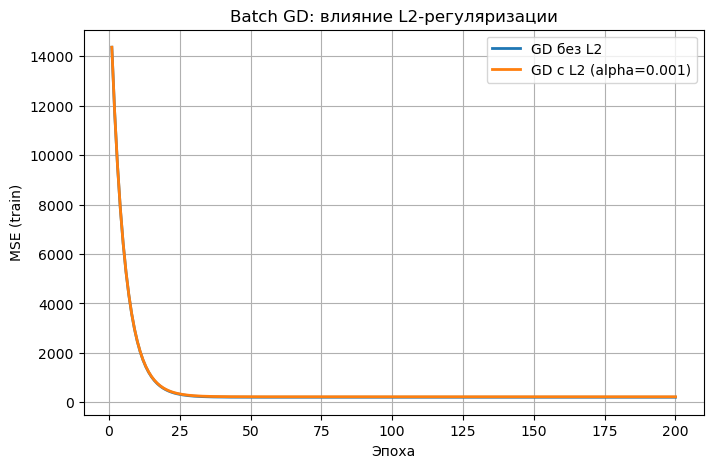

In [22]:
# Графики для batch GD
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(mse_gd_base) + 1), mse_gd_base, label="GD без L2", linewidth=2)
plt.plot(range(1, len(mse_gd_l2) + 1), mse_gd_l2, label=f"GD с L2 (alpha={alpha})", linewidth=2)
plt.xlabel("Эпоха")
plt.ylabel("MSE (train)")
plt.title("Batch GD: влияние L2-регуляризации")
plt.legend()
plt.grid(True)
plt.show()

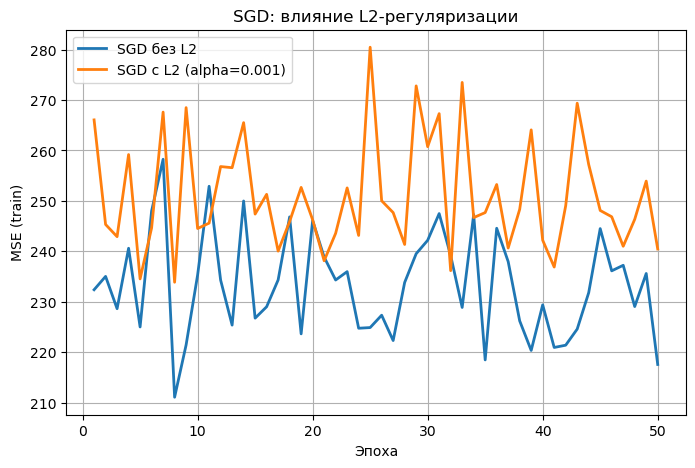

In [23]:
# Графики для SGD
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(mse_sgd_base) + 1), mse_sgd_base, label="SGD без L2", linewidth=2)
plt.plot(range(1, len(mse_sgd_l2) + 1), mse_sgd_l2, label=f"SGD с L2 (alpha={alpha})", linewidth=2)
plt.xlabel("Эпоха")
plt.ylabel("MSE (train)")
plt.title("SGD: влияние L2-регуляризации")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# Оценим качество на тестовой выборке

y_test_pred_gd_base = predict(X_test, w_gd_base)
y_test_pred_gd_l2 = predict(X_test, w_gd_l2)
y_test_pred_sgd_base = predict(X_test, w_sgd_base)
y_test_pred_sgd_l2 = predict(X_test, w_sgd_l2)

print("Test MSE GD без L2:", mse(y_test, y_test_pred_gd_base))
print("Test MSE GD с L2:", mse(y_test, y_test_pred_gd_l2))
print("Test MSE SGD без L2:", mse(y_test, y_test_pred_sgd_base))
print("Test MSE SGD с L2:", mse(y_test, y_test_pred_sgd_l2))


Test MSE GD без L2: 214.01808280948674
Test MSE GD с L2: 213.86086948268894
Test MSE SGD без L2: 220.73007614293618
Test MSE SGD с L2: 233.3503611429919


#### Вывод:

Что я понял, во первых без градиентного спуска на линейной модели с более чем двумя признаками подобрать коэффициенты очень сложно и это потребует очень много самостоятельных посчетов и времени!
Поэтому применяется градиентный спуск! Стахостический градиентный спуск - это как бы разновидность градиентного только он хорошо работает на большом количесвте признаков где нужна скорость и меньшее потребление ресурсов, так как основная разница в том что градиентный спуск считает функцию ошибки на всей выборке, а стохастический на одном случайном обьекте из всей выборки, что значительно снижает вычислительные ресурсы процессора, но проигрывает в качестве , но с каждой инеррацией качество повышается.  
Регуляризация нужно для борьбы с переобучением! Работает путем штрафования за слишком большие показатели коэффициентов! 